# Do the suburbs pay their way? — Fiscal Productivity of Austin-Metro Land

Tests the Strong Towns hypothesis that low-density development doesn't generate enough value (hence
tax) per acre to cover the infrastructure it occupies, so the dense core cross-subsidizes it.

**Method (land/acre break-even).** Infrastructure cost scales with *land area* (linear feet of road &
pipe), revenue with *value*. If cost-to-serve is ~uniform per serviced acre, the break-even per acre =
total tax levy / total acres = the **average tax-per-acre**. Then:

- `revenue        = market_value * effective_tax_rate`
- `tax_per_acre    = revenue / land_acres`
- `breakeven       = sum(revenue) / sum(land_acres)`  *(uniform cost-per-acre)*
- `net_per_acre    = tax_per_acre - breakeven`   → **>0 pays its way (subsidizes); <0 net drain (subsidized)**

**Two lenses** (the result depends on what land counts as 'serviced' — this *is* the key finding):
1. **All land** — includes rural/ag tracts. Break-even is low; the drain shows up as *rural sprawl*.
2. **Developed only** (parcels ≤ `DEVELOPED_ACRE_MAX` acres) — the fair city-vs-suburb test. Break-even
   is higher; low-density *developed* suburbs fall below it.

**Coverage caveat.** Value+geometry come from the City-of-Austin DB (Travis) + Williamson + Hays CAD
FeatureServers. Travis *independent suburbs* — **Lakeway, Pflugerville, Bee Cave, West Lake Hills** —
are NOT covered (their values sit behind TCAD's gated roll). They're excluded here; the last section
documents the one-line PROP_ID join to add them once a roll is obtained. Tax rate is a blended ~2.1%
approximation (rates vary by jurisdiction); since a uniform rate cancels in `net`, the *relative*
pattern is robust — absolute dollars are first-order.

## Setup

In [1]:
import sys, math, urllib.request, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import folium
import h3
import branca.colormap as bcm

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
OUT_DIR = REPO_ROOT / 'outputs'; OUT_DIR.mkdir(exist_ok=True)
PROC = REPO_ROOT / 'processed_data'
METRO_PARQUET = PROC / 'parcels_value_per_acre_metro.parquet'
PLACES_ZIP = PROC / 'tx_places.zip'
HWY_GEOJSON = PROC / 'metro_highways.geojson'
print('ready')

Matplotlib is building the font cache; this may take a moment.


ready


## Config

In [2]:
EFFECTIVE_TAX_RATE = 0.021   # blended city+county+school+special (~2.1%)
DEVELOPED_ACRE_MAX = 5.0     # 'developed' = parcels at or below this acreage (excludes rural/ag)
MIN_CITY_PARCELS = 800       # only report cities with at least this many covered parcels
H3_RES = 8                   # hex resolution for the fiscal-productivity map
MAX_ABS_NET = None           # color clip for net/acre map; None = auto (robust p95 of |net|)

## Load parcels + city labels

In [3]:
g = gpd.read_parquet(METRO_PARQUET)
g['revenue'] = g['market_value'] * EFFECTIVE_TAX_RATE
g['tax_per_acre'] = g['revenue'] / g['land_acres']

# city label via spatial join to Census incorporated places (parcel centroid within place)
if not PLACES_ZIP.exists():
    urllib.request.urlretrieve('https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_48_place_500k.zip', PLACES_ZIP)
places = gpd.read_file(PLACES_ZIP)[['NAME', 'geometry']].to_crs('EPSG:4326')
cent = g.to_crs(2277).geometry.centroid.to_crs(4326)
g['lon'] = cent.x.values; g['lat'] = cent.y.values
pts = gpd.GeoDataFrame(g[['revenue', 'land_acres', 'market_value', 'value_per_acre']].copy(),
                       geometry=cent, crs='EPSG:4326')
g['city'] = gpd.sjoin(pts, places, how='left', predicate='within')['NAME'].fillna('Unincorporated').values
print(f'{len(g):,} parcels across {g["county"].nunique()} counties; '
      f'{g["city"].nunique()} place labels')

576,855 parcels across 3 counties; 46 place labels


## The two-lens break-even
`net_dollars` per parcel = revenue − breakeven × acres. Summed over an area it gives that area's annual
surplus (+) or deficit (−) under the uniform-cost-per-acre assumption.

In [4]:
def fiscal(df):
    be = df['revenue'].sum() / df['land_acres'].sum()
    out = df.copy()
    out['net_dollars'] = out['revenue'] - be * out['land_acres']
    return out, be

all_land, be_all = fiscal(g)
developed, be_dev = fiscal(g[g['land_acres'] <= DEVELOPED_ACRE_MAX])
print(f'break-even (all land)       = ${be_all:,.0f}/acre/yr')
print(f'break-even (developed only) = ${be_dev:,.0f}/acre/yr')
print(f'total levy modeled          = ${g["revenue"].sum()/1e9:.2f}B/yr')

break-even (all land)       = $9,566/acre/yr
break-even (developed only) = $34,624/acre/yr
total levy modeled          = $10.46B/yr


## Density gradient — net per acre across value-per-acre deciles

,decile,parcels,acres,med_vpa,net_M,net_per_acre
0,0,57686,"868,023","$70,364","$-7,527M","$-8,672"
1,1,57685,"83,978","$552,294",$+83M,$+986
2,2,57686,"32,577","$1,333,227",$+548M,"$+16,808"
3,3,57685,"18,198","$1,802,026",$+510M,"$+28,015"
4,4,57686,"16,452","$2,112,788",$+573M,"$+34,804"
5,5,57685,"14,122","$2,394,524",$+575M,"$+40,693"
6,6,57685,"14,490","$2,693,729",$+682M,"$+47,097"
7,7,57686,"13,993","$3,062,171",$+769M,"$+54,945"
8,8,57685,"15,325","$3,628,193","$+1,037M","$+67,679"
9,9,57686,"16,772","$5,733,218","$+2,751M","$+164,050"


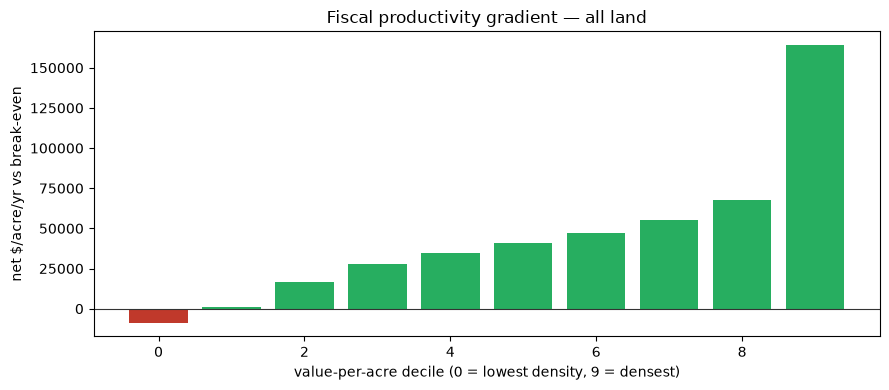

In [5]:
g_all, _ = fiscal(g)
g_all['decile'] = pd.qcut(g_all['value_per_acre'], 10, labels=False, duplicates='drop')
grad = g_all.groupby('decile').agg(parcels=('net_dollars','size'), acres=('land_acres','sum'),
        med_vpa=('value_per_acre','median'), net_M=('net_dollars', lambda s: s.sum()/1e6)).reset_index()
grad['net_per_acre'] = grad['net_M']*1e6 / grad['acres']
display(grad.style.format({'med_vpa':'${:,.0f}', 'net_M':'${:+,.0f}M', 'acres':'{:,.0f}',
                           'net_per_acre':'${:+,.0f}'}))
fig, ax = plt.subplots(figsize=(9,4))
colors = ['#c0392b' if v < 0 else '#27ae60' for v in grad['net_per_acre']]
ax.bar(grad['decile'], grad['net_per_acre'], color=colors)
ax.axhline(0, color='#333', lw=0.8)
ax.set_xlabel('value-per-acre decile (0 = lowest density, 9 = densest)')
ax.set_ylabel('net $/acre/yr vs break-even')
ax.set_title('Fiscal productivity gradient — all land')
plt.tight_layout(); plt.savefig(OUT_DIR/'fiscal_gradient.png', dpi=110); plt.show()

## Per-city surplus / deficit (developed-land lens — the fair city-vs-suburb test)

,city,parcels,acres,rev_M,net_M,med_vpa,net_per_acre
44,Wimberley,1287,"1,963",$20M,$-48M,"$589,582","$-24,472"
40,Unincorporated,107095,"80,382","$1,075M","$-1,708M","$1,695,455","$-21,252"
19,Jarrell,1797,760,$12M,$-14M,"$1,581,551","$-18,813"
36,Taylor,7639,"2,723",$47M,$-47M,"$1,142,714","$-17,327"
39,Uhland,1008,346,$6M,$-6M,"$2,313,357","$-16,166"
22,Liberty Hill,2886,"1,034",$23M,$-12M,"$2,300,735","$-12,020"
11,Dripping Springs,2863,"1,575",$37M,$-18M,"$2,547,846","$-11,354"
29,San Marcos,13727,"3,821",$106M,$-26M,"$1,980,776","$-6,808"
45,Woodcreek,837,273,$8M,$-1M,"$1,619,558","$-5,309"
5,Brushy Creek,7176,"2,558",$80M,$-9M,"$2,503,301","$-3,528"


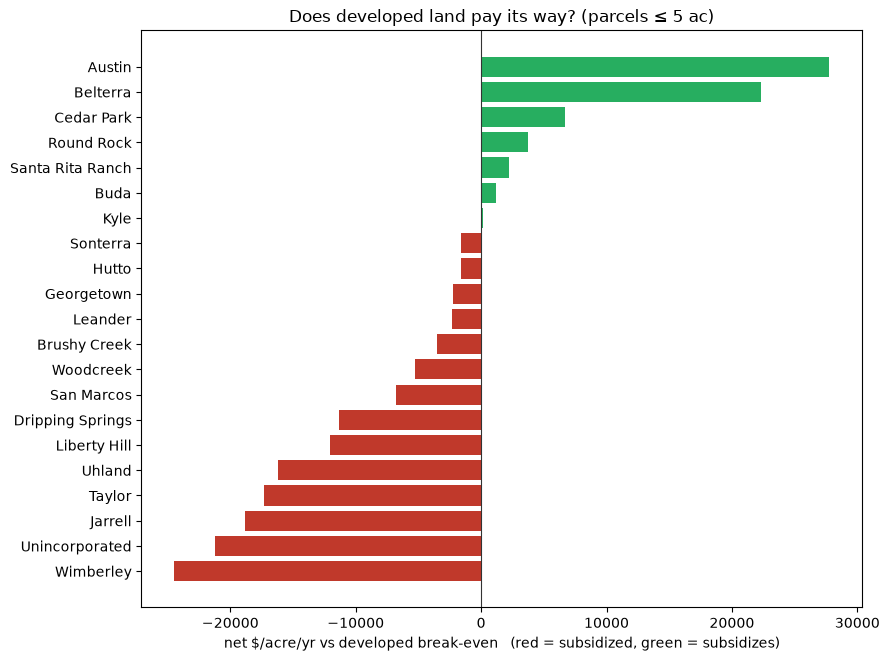

In [6]:
def by_city(df, be):
    d = df.assign(net_dollars=df['revenue'] - be*df['land_acres'])
    c = d.groupby('city').agg(parcels=('net_dollars','size'), acres=('land_acres','sum'),
        rev_M=('revenue', lambda s:s.sum()/1e6), net_M=('net_dollars', lambda s:s.sum()/1e6),
        med_vpa=('value_per_acre','median')).reset_index()
    c['net_per_acre'] = c['net_M']*1e6 / c['acres']
    return c[c['parcels'] >= MIN_CITY_PARCELS].sort_values('net_per_acre')

dev = g[g['land_acres'] <= DEVELOPED_ACRE_MAX]
city_dev = by_city(dev, be_dev)
display(city_dev.style.format({'rev_M':'${:,.0f}M', 'net_M':'${:+,.0f}M', 'med_vpa':'${:,.0f}',
                               'acres':'{:,.0f}', 'net_per_acre':'${:+,.0f}'}))

fig, ax = plt.subplots(figsize=(9, max(4, 0.32*len(city_dev))))
colors = ['#c0392b' if v < 0 else '#27ae60' for v in city_dev['net_per_acre']]
ax.barh(city_dev['city'], city_dev['net_per_acre'], color=colors)
ax.axvline(0, color='#333', lw=0.8)
ax.set_xlabel('net $/acre/yr vs developed break-even   (red = subsidized, green = subsidizes)')
ax.set_title(f'Does developed land pay its way? (parcels ≤ {DEVELOPED_ACRE_MAX:g} ac)')
plt.tight_layout(); plt.savefig(OUT_DIR/'fiscal_by_city.png', dpi=110); plt.show()

## Fiscal-productivity map — does this land pay for itself?
H3 hexes colored by `net_per_acre` (diverging): **red = net drain** (below break-even, subsidized),
**green = surplus** (above break-even, subsidizes the rest). Major highways overlaid for orientation.

In [7]:
agg = pd.DataFrame({'hex': [h3.latlng_to_cell(la, lo, H3_RES) for la, lo in zip(g['lat'], g['lon'])],
                    'revenue': g['revenue'].values, 'land_acres': g['land_acres'].values})
hx = agg.groupby('hex').agg(revenue=('revenue','sum'), land_acres=('land_acres','sum'),
                            n=('hex','size')).reset_index()
hx['net_per_acre'] = hx['revenue']/hx['land_acres'] - be_all
clip = MAX_ABS_NET or float(np.percentile(np.abs(hx['net_per_acre']), 95))
cmap = bcm.LinearColormap(['#b2182b', '#ef8a62', '#f7f7f7', '#67a9cf', '#2166ac'],
    vmin=-clip, vmax=clip, caption=f'net $/acre/yr vs break-even (${be_all:,.0f}/acre)')
def col(v): return cmap(max(-clip, min(clip, v)))
clat, clon = float(g['lat'].mean()), float(g['lon'].mean())
m = folium.Map(location=[clat, clon], zoom_start=10, tiles='CartoDB positron')
for _, r in hx.iterrows():
    folium.Polygon([[a, b] for a, b in h3.cell_to_boundary(r['hex'])], color='#888', weight=0.2,
        fill=True, fill_color=col(r['net_per_acre']), fill_opacity=0.72,
        tooltip=f"net ${r['net_per_acre']:+,.0f}/acre · {int(r['n'])} parcels").add_to(m)
if HWY_GEOJSON.exists():
    hwy = gpd.read_file(HWY_GEOJSON)
    hwy['geometry'] = hwy.to_crs(2277).geometry.simplify(150).to_crs(4326)
    gj = hwy.to_json()
    folium.GeoJson(gj, style_function=lambda f: {'color':'#fff','weight':4,'opacity':0.9}).add_to(m)
    folium.GeoJson(gj, style_function=lambda f: {'color':'#222','weight':1.6,'opacity':0.95}).add_to(m)
cmap.add_to(m)
out = OUT_DIR / 'map_fiscal_productivity.html'; m.save(str(out)); print('wrote', out)

wrote /Users/chaseeasterling/GitHub/fire-incident-analysis/outputs/map_fiscal_productivity.html


## Adding the Travis suburbs later (Lakeway, Pflugerville, …)
Those parcels' geometry + acreage + `situs_city` are already free from the TCAD GIS layer; only the
**value** is gated. Once you have a roll CSV (`PROP_ID, market_value`) from a TCAD public-information
request or TaxNetUSA, it folds in here — then re-run the notebook:
```python
# 1. pull TCAD GIS geometry for the missing cities (PROP_ID, situs_city, tcad_acres, geometry)
#    from gis.traviscountytx.gov/.../TCAD_public/MapServer/0  where situs_city IN ('LAKEWAY','PFLUGERVILLE')
# 2. roll = pd.read_csv('processed_data/tcad_roll.csv')          # PROP_ID, market_value
# 3. add = tcad_gis.merge(roll, on='PROP_ID')                    # geometry + value
#    add = add.rename(columns={'tcad_acres':'land_acres'}); add['county']='travis'
#    add['value_per_acre'] = add['market_value']/add['land_acres']
# 4. g = pd.concat([g, add[g.columns.intersection(add.columns)]])  # then re-run from 'Load parcels'
```

## Findings (with current coverage)
- **All-land lens:** Austin's dense core runs a large surplus; the biggest *deficit* is rural/ag
  unincorporated land — under this framing the drain is **sprawl/rural**, not incorporated suburbs.
- **Developed-land lens** (the fair test): **Austin is strongly net-positive per acre**, while most
  measured suburbs fall **below** the developed break-even — i.e. low-density developed suburban land
  underpays for the infrastructure it occupies, consistent with the Strong Towns hypothesis.
- The honest takeaway: whether suburbs 'drain the city' hinges on what land you hold to the
  cost-per-acre standard. Among **developed** land, the density→productivity gradient is real and steep.